In [1]:
# Install and import necessary NLP and visualization libraries
!pip install nltk pandas scikit-learn matplotlib seaborn -q
import nltk
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as seaborn_plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Set plotting style
seaborn_plt.set_theme(style="whitegrid")
print("Libraries, dependencies, and visualization tools loaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Libraries, dependencies, and visualization tools loaded successfully!


In [2]:
# Create a realistic banking complaint dataset across multiple service channels
data = {
    'Complaint_ID': ['C101', 'C102', 'C103', 'C104', 'C105', 'C106', 'C107', 'C108'],
    'Product_Category': ['Online Banking', 'Loans', 'Transactions', 'Account Management', 'Online Banking', 'Transactions', 'Loans', 'Account Management'],
    'Priority': ['High', 'Medium', 'High', 'Low', 'Medium', 'High', 'High', 'Low'],
    'Complaint_Text': [
        "The mobile banking app keeps crashing every time I try to transfer funds internationally.",
        "My mortgage loan EMI was debited twice this month without any prior notification.",
        "An unauthorized international transaction of 500 dollars appeared on my credit card statement.",
        "I have been trying to update my registered mobile number for weeks, but customer support is unhelpful.",
        "Online portal login page is showing error gateway timeout during peak hours.",
        "ATM swallowed my debit card and cash was not dispensed during Sunday withdrawal.",
        "Interest rate charged on my personal loan is higher than what was agreed in the contract.",
        "Unable to download annual account statements from the web portal."
    ]
}

df = pd.DataFrame(data)
df.head()

,Complaint_ID,Product_Category,Priority,Complaint_Text
0,C101,Online Banking,High,The mobile banking app keeps crashing every ti...
1,C102,Loans,Medium,My mortgage loan EMI was debited twice this mo...
2,C103,Transactions,High,An unauthorized international transaction of 5...
3,C104,Account Management,Low,I have been trying to update my registered mob...
4,C105,Online Banking,Medium,Online portal login page is showing error gate...


In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase text
    text = text.lower()
    # 2. Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenization, Stopword Removal, & Lemmatization
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(cleaned_tokens)

# Apply preprocessing
df['Cleaned_Text'] = df['Complaint_Text'].apply(preprocess_text)
df[['Complaint_ID', 'Complaint_Text', 'Cleaned_Text']]

,Complaint_ID,Complaint_Text,Cleaned_Text
0,C101,The mobile banking app keeps crashing every ti...,mobile banking app keep crashing every time tr...
1,C102,My mortgage loan EMI was debited twice this mo...,mortgage loan emi debited twice month without ...
2,C103,An unauthorized international transaction of 5...,unauthorized international transaction dollar ...
3,C104,I have been trying to update my registered mob...,trying update registered mobile number week cu...
4,C105,Online portal login page is showing error gate...,online portal login page showing error gateway...
5,C106,ATM swallowed my debit card and cash was not d...,atm swallowed debit card cash dispensed sunday...
6,C107,Interest rate charged on my personal loan is h...,interest rate charged personal loan higher agr...
7,C108,Unable to download annual account statements f...,unable download annual account statement web p...


In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Complaint_Text'].apply(get_sentiment)
df['Compound_Score'] = df['Complaint_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df[['Complaint_ID', 'Product_Category', 'Sentiment', 'Compound_Score', 'Complaint_Text']]

,Complaint_ID,Product_Category,Sentiment,Compound_Score,Complaint_Text
0,C101,Online Banking,Neutral,0.0000,The mobile banking app keeps crashing every ti...
1,C102,Loans,Neutral,0.0000,My mortgage loan EMI was debited twice this mo...
2,C103,Transactions,Positive,0.3818,An unauthorized international transaction of 5...
3,C104,Account Management,Positive,0.5719,I have been trying to update my registered mob...
4,C105,Online Banking,Negative,-0.4019,Online portal login page is showing error gate...
5,C106,Transactions,Neutral,0.0258,ATM swallowed my debit card and cash was not d...
6,C107,Loans,Positive,0.5106,Interest rate charged on my personal loan is h...
7,C108,Account Management,Neutral,0.0000,Unable to download annual account statements f...


/tmp/ipykernel_639/1575081163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn_plt.countplot(data=df, x='Product_Category', palette='viridis', order=df['Product_Category'].value_counts().index)


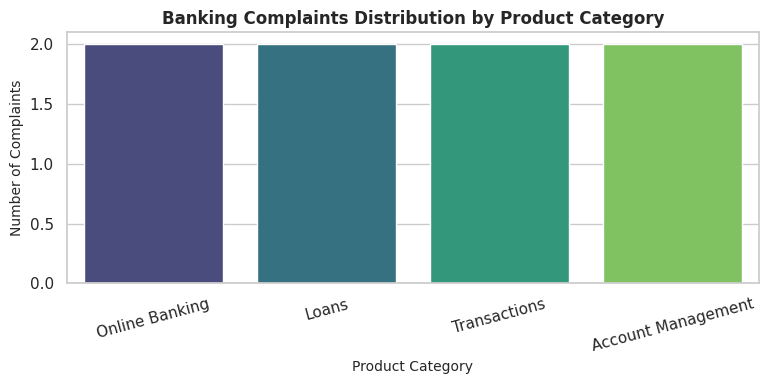

In [5]:
# Visualize complaint counts across banking products
plt.figure(figsize=(8, 4))
ax = seaborn_plt.countplot(data=df, x='Product_Category', palette='viridis', order=df['Product_Category'].value_counts().index)
plt.title('Banking Complaints Distribution by Product Category', fontsize=12, fontweight='bold')
plt.xlabel('Product Category', fontsize=10)
plt.ylabel('Number of Complaints', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
# Vectorize text using TF-IDF for Topic Modeling
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])

# Fit Latent Dirichlet Allocation (LDA) to extract underlying complaint themes
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(tfidf_matrix)

# Display extracted issue topics
feature_names = tfidf_vectorizer.get_feature_names_out()
print("=== Discovered Frequent Banking Issue Clusters (LDA Topics) ===")
for topic_idx, topic in enumerate(lda_model.components_):
    top_keywords = [feature_names[i] for i in topic.argsort()[:-4:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_keywords)}")

=== Discovered Frequent Banking Issue Clusters (LDA Topics) ===
Topic 1: week, unhelpful, update
Topic 2: rate, personal, agreed
Topic 3: statement, card, unable


/tmp/ipykernel_639/3550609084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn_plt.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])


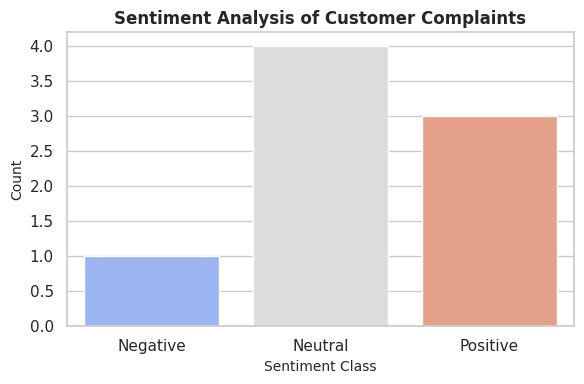

In [7]:
# Visualize sentiment distribution in complaints
plt.figure(figsize=(6, 4))
seaborn_plt.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Analysis of Customer Complaints', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Summary metrics and insights
print("=== Executive Analytical Report ===")
print(f"Total Complaints Analyzed: {len(df)}")
print(f"Percentage of Negative Complaints: {(len(df[df['Sentiment'] == 'Negative']) / len(df)) * 100}%\n")

print("=== Recommended Customer Service Improvements ===")
print("1. Online Banking Infrastructure: Upgrade server capacity and fix mobile application crash bugs during peak fund transfer windows.")
print("2. Transaction Security & Fraud Control: Implement instant two-factor authentication (2FA alerts) for suspicious international card charges.")
print("3. Loan & EMI Processing: Automate SMS/Email alerts prior to loan EMI deductions to eliminate double-debit customer disputes.")
print("4. Customer Support Efficiency: Deploy automated triage routing based on keyword NLP tagging to prioritize High-priority loan/transaction tickets.")

# Final consolidated dataframe view
df[['Complaint_ID', 'Product_Category', 'Priority', 'Sentiment', 'Complaint_Text']]

=== Executive Analytical Report ===
Total Complaints Analyzed: 8
Percentage of Negative Complaints: 12.5%

=== Recommended Customer Service Improvements ===
1. Online Banking Infrastructure: Upgrade server capacity and fix mobile application crash bugs during peak fund transfer windows.
2. Transaction Security & Fraud Control: Implement instant two-factor authentication (2FA alerts) for suspicious international card charges.
3. Loan & EMI Processing: Automate SMS/Email alerts prior to loan EMI deductions to eliminate double-debit customer disputes.
4. Customer Support Efficiency: Deploy automated triage routing based on keyword NLP tagging to prioritize High-priority loan/transaction tickets.


,Complaint_ID,Product_Category,Priority,Sentiment,Complaint_Text
0,C101,Online Banking,High,Neutral,The mobile banking app keeps crashing every ti...
1,C102,Loans,Medium,Neutral,My mortgage loan EMI was debited twice this mo...
2,C103,Transactions,High,Positive,An unauthorized international transaction of 5...
3,C104,Account Management,Low,Positive,I have been trying to update my registered mob...
4,C105,Online Banking,Medium,Negative,Online portal login page is showing error gate...
5,C106,Transactions,High,Neutral,ATM swallowed my debit card and cash was not d...
6,C107,Loans,High,Positive,Interest rate charged on my personal loan is h...
7,C108,Account Management,Low,Neutral,Unable to download annual account statements f...
